In [23]:
import numpy as np
import scipy.stats as stats
import pandas as pd
import polars as pl
import matplotlib.pyplot as plt
from dynamic_routing_analysis import decoding_utils
# from dynamic_routing_analysis import plot_utils
# import dynamic_routing_analysis as dra
# import pingouin as pg
import os

import matplotlib
import matplotlib.font_manager as fm

matplotlib.rcParams['font.size'] = 8
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42
fm.FontProperties().set_family('arial')

%load_ext autoreload
%autoreload 2
%matplotlib inline
# %matplotlib widget

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
baseline_path = r"s3://aind-scratch-data/dynamic-routing/decoding/results/decode_context_baseline_500ms_all_units_strict_drift_0/"
vis_target_path = r"s3://aind-scratch-data/dynamic-routing/decoding/results/baseline_subtract_decode_context_vis_target_100ms_window_50ms_bin_all_units_strict_drift_0/"
aud_target_path = r"s3://aind-scratch-data/dynamic-routing/decoding/results/baseline_subtract_decode_context_aud_target_100ms_window_50ms_bin_all_units_strict_drift_0/"

In [3]:
session_table_path=r"\\allen\programs\mindscope\workgroups\dynamicrouting\Ethan\CO decoding results\session_table_v0.272.parquet"
session_table=pl.read_parquet(session_table_path)

dr_session_list=(
    session_table.filter(
    pl.col('project')=="DynamicRouting",
    pl.col('is_production'),
    pl.col('is_annotated'),
    pl.col('issues')==[],
    # pl.col('is_good_behavior').eq(True),
    # pl.col('is_engaged').eq(True),
    )['session_id'].to_list()
    )

In [158]:
block_dprime_threshold=1.0

good_behavior_table={
    'session_id':[],
    'n_good_vis_blocks':[],
    'n_good_aud_blocks':[],
}

for sel_session in dr_session_list:
    
    n_good_vis_blocks=np.sum(session_table.filter(pl.col('session_id') == sel_session)['cross_modality_dprime_vis_blocks'].to_numpy()[0]>=block_dprime_threshold)
    n_good_aud_blocks=np.sum(session_table.filter(pl.col('session_id') == sel_session)['cross_modality_dprime_aud_blocks'].to_numpy()[0]>=block_dprime_threshold)

    good_behavior_table['session_id'].append(sel_session)
    good_behavior_table['n_good_vis_blocks'].append(n_good_vis_blocks)
    good_behavior_table['n_good_aud_blocks'].append(n_good_aud_blocks)

good_behavior_table=pd.DataFrame(good_behavior_table)
dr_good_behavior_list=good_behavior_table.query('n_good_vis_blocks>=2 and n_good_aud_blocks>=2')['session_id'].values

In [4]:
#define grouping columns
grouping_cols = {
    'session_id',
    'structure',
    'electrode_group_names',
    'unit_subsample_size',
    'bin_center',
    'bin_size',
    'time_aligned_to',
    'coefs',
    'unit_ids',
}

#toggle combine_multi_probe_rec
combine_multi_probe_rec = True

if combine_multi_probe_rec:
    combine_multi_probe_expr = pl.col('electrode_group_names').list.len().gt(1) | pl.col('is_sole_recording').eq(True)
else:
    combine_multi_probe_expr = pl.col('electrode_group_names').list.len().eq(1) | pl.col('is_sole_recording').eq(True)


In [19]:
results_path = baseline_path

#get single session, keep coefs (and unit ids?)

#include repeats, but don't need predict_proba

#one row per repeat, with coefs and unit ids

### make separate query to include repeats - specify session
sel_session='742903_2024-10-22' #the golden session
# sel_session='670180_2023-07-27' #a templeton session
decoder_coefs_single_session = (
    pl.scan_parquet(results_path)
    .filter(
        pl.col('session_id').eq(sel_session),
    )
    .with_columns(
        pl.col('electrode_group_names').flatten().n_unique().eq(1).over({'session_id','structure'}).alias('is_sole_recording'),     
    )
    .filter(
        combine_multi_probe_expr,
        pl.col('is_all_trials').eq(True),
    )
    .sort('session_id', 'structure', 'shift_idx', 'repeat_idx', 'time_aligned_to', 'bin_center', descending=False, maintain_order=True)
    .collect()
    .with_columns([
        pl.col('unit_ids').list.len().alias('n_units'),
        pl.col("electrode_group_names").list.n_unique().alias("n_probes"),
        pl.col("electrode_group_names")
        .list.eval(pl.element().str.replace("probe", ""))
        .list.join("")
        .alias("probe")
    ])
    .drop(
        'shift_idx', 'is_all_trials', 'electrode_group_names', 'unit_criteria', 'is_sole_recording', 
        'predict_proba', 'predict_proba_all_trials', 'decision_function', 'decision_function_all',
        'balanced_accuracy_test', 'balanced_accuracy_train', 'trial_indices', 'labels', 
        'train_test_split_label', 
    )
)

In [20]:
decoder_coefs_single_session

time_aligned_to,bin_size,sliding_window_size,bin_center,repeat_idx,unit_ids,coefs,session_id,structure,unit_subsample_size,n_units,n_probes,probe
enum,f64,null,f64,u16,list[str],list[f64],str,str,u16,u64,u64,str
"""stim_start_time""",0.5,null,-0.25,0,"[""742903_2024-10-22_A-100"", ""742903_2024-10-22_A-103"", … ""742903_2024-10-22_A-99""]","[0.314301, -0.213643, … 0.261769]","""742903_2024-10-22""","""ACAd""",null,35,1,"""A"""
"""stim_start_time""",0.5,null,-0.25,0,"[""742903_2024-10-22_A-302"", ""742903_2024-10-22_A-303"", … ""742903_2024-10-22_A-62""]","[0.317434, -0.112744, … 0.37137]","""742903_2024-10-22""","""ACAv""",null,25,1,"""A"""
"""stim_start_time""",0.5,null,-0.25,0,"[""742903_2024-10-22_C-10"", ""742903_2024-10-22_C-107"", … ""742903_2024-10-22_C-91""]","[0.127628, 0.301703, … -0.62352]","""742903_2024-10-22""","""CP""",null,46,1,"""C"""
"""stim_start_time""",0.5,null,-0.25,0,"[""742903_2024-10-22_B-22"", ""742903_2024-10-22_B-23"", … ""742903_2024-10-22_B-666""]","[0.09843, 0.250491, … -0.073157]","""742903_2024-10-22""","""GU""",null,39,1,"""B"""
"""stim_start_time""",0.5,null,-0.25,0,"[""742903_2024-10-22_F-10"", ""742903_2024-10-22_F-105"", … ""742903_2024-10-22_F-99""]","[0.005146, 0.212802, … -0.364959]","""742903_2024-10-22""","""ILA""",null,109,1,"""F"""
…,…,…,…,…,…,…,…,…,…,…,…,…
"""stim_start_time""",0.5,null,-0.25,0,"[""742903_2024-10-22_E-1012"", ""742903_2024-10-22_E-1013"", … ""742903_2024-10-22_E-84""]","[0.083731, -0.430376, … -0.002561]","""742903_2024-10-22""","""ORBvl""",null,193,1,"""E"""
"""stim_start_time""",0.5,null,-0.25,0,"[""742903_2024-10-22_A-320"", ""742903_2024-10-22_A-322"", … ""742903_2024-10-22_F-657""]","[-0.09597, 0.645392, … 0.239431]","""742903_2024-10-22""","""PL""",null,20,2,"""AF"""
"""stim_start_time""",0.5,null,-0.25,0,"[""742903_2024-10-22_B-130"", ""742903_2024-10-22_B-136"", … ""742903_2024-10-22_C-695""]","[-0.104328, -0.23757, … -0.020232]","""742903_2024-10-22""","""SSp""",null,164,2,"""BC"""


In [26]:
# decoder_coefs = (
#     pl.scan_parquet(results_path)
#     .filter(
#         pl.col('session_id').is_in(dr_session_list),
#     )
#     .with_columns(
#         pl.col('electrode_group_names').flatten().n_unique().eq(1).over({'session_id','structure'}).alias('is_sole_recording'),     
#     )
#     .filter(
#         combine_multi_probe_expr,
#         pl.col('is_all_trials').eq(True),
#     )
#     .sort('session_id', 'structure', 'shift_idx', 'repeat_idx', 'time_aligned_to', 'bin_center', descending=False, maintain_order=True)
#     .collect()
#     .with_columns([
#         pl.col('unit_ids').list.len().alias('n_units'),
#         pl.col("electrode_group_names").list.n_unique().alias("n_probes"),
#         pl.col("electrode_group_names")
#         .list.eval(pl.element().str.replace("probe", ""))
#         .list.join("")
#         .alias("probe")
#     ])
#     .drop(
#         'shift_idx', 'is_all_trials', 'electrode_group_names', 'unit_criteria', 'is_sole_recording', 
#         'predict_proba', 'predict_proba_all_trials', 'decision_function', 'decision_function_all',
#         'balanced_accuracy_test', 'balanced_accuracy_train', 'trial_indices', 'labels', 
#         'train_test_split_label', 
#     )
# )

baseline_decoder_coefs = decoding_utils.load_decoder_coefs(results_path=baseline_path,session_list=dr_session_list).to_pandas()
vis_target_decoder_coefs = decoding_utils.load_decoder_coefs(results_path=vis_target_path,session_list=dr_session_list).to_pandas()
aud_target_decoder_coefs = decoding_utils.load_decoder_coefs(results_path=aud_target_path,session_list=dr_session_list).to_pandas()

In [130]:
sel_session='742903_2024-10-22'
sel_structure='ORBl'

sel_bin_center=0.125

baseline_unit_ids=baseline_decoder_coefs.query('session_id==@sel_session and structure==@sel_structure')['unit_ids'].values[0]
baseline_coefs=baseline_decoder_coefs.query('session_id==@sel_session and structure==@sel_structure')['coefs'].values[0]

vis_target_unit_ids=vis_target_decoder_coefs.query('session_id==@sel_session and structure==@sel_structure and bin_center==@sel_bin_center')['unit_ids'].values[0]
vis_target_coefs=vis_target_decoder_coefs.query('session_id==@sel_session and structure==@sel_structure and bin_center==@sel_bin_center')['coefs'].values[0]

aud_target_unit_ids=aud_target_decoder_coefs.query('session_id==@sel_session and structure==@sel_structure and bin_center==@sel_bin_center')['unit_ids'].values[0]
aud_target_coefs=aud_target_decoder_coefs.query('session_id==@sel_session and structure==@sel_structure and bin_center==@sel_bin_center')['coefs'].values[0]

In [131]:
# vis_target_decoder_coefs

In [223]:
baseline_unit_ids==vis_target_unit_ids

array([ True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True])

In [133]:
stats.pearsonr(baseline_coefs, vis_target_coefs)

PearsonRResult(statistic=-0.432371582878328, pvalue=0.0033780779661864804)

In [134]:
stats.pearsonr(aud_target_coefs, vis_target_coefs)

PearsonRResult(statistic=0.300308256540148, pvalue=0.04763010414274752)

In [135]:
A = baseline_coefs
B = vis_target_coefs
# compute cosine similarity
cosine = np.dot(A, B) / (np.linalg.norm(A) * np.linalg.norm(B))
print("Cosine Similarity:", cosine)

Cosine Similarity: -0.4084604518852231


In [137]:
def unit_vector(vector):
    """ Returns the unit vector of the vector.  """
    return vector / np.linalg.norm(vector)

def angle_between(v1, v2):
    """ Returns the angle in radians between vectors 'v1' and 'v2'::

            >>> angle_between((1, 0, 0), (0, 1, 0))
            1.5707963267948966
            >>> angle_between((1, 0, 0), (1, 0, 0))
            0.0
            >>> angle_between((1, 0, 0), (-1, 0, 0))
            3.141592653589793
    """
    v1_u = unit_vector(v1)
    v2_u = unit_vector(v2)
    return np.arccos(np.clip(np.dot(v1_u, v2_u), -1.0, 1.0))

In [141]:
# np.rad2deg(angle_between(aud_target_coefs, vis_target_coefs))
np.rad2deg(angle_between((1, 0, 0), (0, 1, 0)))

90.0

In [95]:
baseline_decoder_coefs['bin_center'] = baseline_decoder_coefs['bin_center'].round(3)
vis_target_decoder_coefs['bin_center'] = vis_target_decoder_coefs['bin_center'].round(3)
aud_target_decoder_coefs['bin_center'] = aud_target_decoder_coefs['bin_center'].round(3)

In [142]:
#for each session, structure, and bin_center, compute correlation between baseline coefs and vis target coefs, and between baseline coefs and aud target coefs. Also compute cosine similarity.

context_dimension_comparison={
    'session_id': [],
    'structure': [],
    'bin_center': [],
    'baseline_vis_corr_r': [],
    'baseline_vis_corr_p': [],
    'baseline_aud_corr_r': [],
    'baseline_aud_corr_p': [],
    'vis_aud_corr_r': [],
    'vis_aud_corr_p': [],
    'baseline_vis_cosine': [],
    'baseline_aud_cosine': [],
    'vis_aud_cosine': [],
    'baseline_vis_angle': [],
    'baseline_aud_angle': [],
    'vis_aud_angle': [],
}

for session in dr_session_list:
    for structure in baseline_decoder_coefs.query('session_id==@session')['structure'].unique():
        #assumes only one bin center for baseline results
        baseline_unit_ids=baseline_decoder_coefs.query('session_id==@session and structure==@structure')['unit_ids'].values[0]
        baseline_coefs=baseline_decoder_coefs.query('session_id==@session and structure==@structure')['coefs'].values[0]

        for bin_center in vis_target_decoder_coefs['bin_center'].unique():
            #get coefs and unit ids for baseline, vis target, and aud target decoders

            if len(vis_target_decoder_coefs.query('session_id==@session and structure==@structure and bin_center==@bin_center'))==0:
                continue
            elif len(aud_target_decoder_coefs.query('session_id==@session and structure==@structure and bin_center==@bin_center'))==0:
                continue
            
            vis_target_unit_ids=vis_target_decoder_coefs.query('session_id==@session and structure==@structure and bin_center==@bin_center')['unit_ids'].values[0]
            vis_target_coefs=vis_target_decoder_coefs.query('session_id==@session and structure==@structure and bin_center==@bin_center')['coefs'].values[0]

            aud_target_unit_ids=aud_target_decoder_coefs.query('session_id==@session and structure==@structure and bin_center==@bin_center')['unit_ids'].values[0]
            aud_target_coefs=aud_target_decoder_coefs.query('session_id==@session and structure==@structure and bin_center==@bin_center')['coefs'].values[0]

            # compute correlation and cosine similarity
            baseline_vis_corr = stats.pearsonr(baseline_coefs, vis_target_coefs)
            baseline_aud_corr = stats.pearsonr(baseline_coefs, aud_target_coefs)
            vis_aud_corr = stats.pearsonr(vis_target_coefs, aud_target_coefs)

            baseline_vis_cosine = np.dot(baseline_coefs, vis_target_coefs) / (np.linalg.norm(baseline_coefs) * np.linalg.norm(vis_target_coefs))
            baseline_aud_cosine = np.dot(baseline_coefs, aud_target_coefs) / (np.linalg.norm(baseline_coefs) * np.linalg.norm(aud_target_coefs))
            vis_aud_cosine = np.dot(vis_target_coefs, aud_target_coefs) / (np.linalg.norm(vis_target_coefs) * np.linalg.norm(aud_target_coefs))

            baseline_vis_angle = np.rad2deg(angle_between(baseline_coefs, vis_target_coefs))
            baseline_aud_angle = np.rad2deg(angle_between(baseline_coefs, aud_target_coefs))
            vis_aud_angle = np.rad2deg(angle_between(vis_target_coefs, aud_target_coefs))

            # append results to context_dimension_comparison
            context_dimension_comparison['session_id'].append(session)
            context_dimension_comparison['structure'].append(structure)
            context_dimension_comparison['bin_center'].append(bin_center)
            context_dimension_comparison['baseline_vis_corr_r'].append(baseline_vis_corr[0])
            context_dimension_comparison['baseline_vis_corr_p'].append(baseline_vis_corr[1])
            context_dimension_comparison['baseline_aud_corr_r'].append(baseline_aud_corr[0])
            context_dimension_comparison['baseline_aud_corr_p'].append(baseline_aud_corr[1])
            context_dimension_comparison['vis_aud_corr_r'].append(vis_aud_corr[0])
            context_dimension_comparison['vis_aud_corr_p'].append(vis_aud_corr[1])
            context_dimension_comparison['baseline_vis_cosine'].append(baseline_vis_cosine)
            context_dimension_comparison['baseline_aud_cosine'].append(baseline_aud_cosine)
            context_dimension_comparison['vis_aud_cosine'].append(vis_aud_cosine)
            context_dimension_comparison['baseline_vis_angle'].append(baseline_vis_angle)
            context_dimension_comparison['baseline_aud_angle'].append(baseline_aud_angle)
            context_dimension_comparison['vis_aud_angle'].append(vis_aud_angle)

context_dimension_comparison_df = pd.DataFrame(context_dimension_comparison)

In [ ]:
# vis_target_decoder_coefs.query('session_id==@session and structure==@structure and bin_center==@bin_center')
# vis_target_decoder_coefs.query('session_id==@session')
# bin_center
# session
# np.unique(context_dimension_comparison['session_id']).shape

(62,)

In [ ]:
# decoder_coefs_single_session['bin_center'].unique()
# baseline_decoder_coefs.query('session_id==@session')
# structure

'NB'

In [ ]:
# context_dimension_comparison_df['baseline_vis_corr_r']=np.vstack(context_dimension_comparison_df['baseline_vis_corr'])[:,0]
# context_dimension_comparison_df['baseline_vis_corr_p']=np.vstack(context_dimension_comparison_df['baseline_vis_corr'])[:,1]
# context_dimension_comparison_df['baseline_aud_corr_r']=np.vstack(context_dimension_comparison_df['baseline_aud_corr'])[:,0]
# context_dimension_comparison_df['baseline_aud_corr_p']=np.vstack(context_dimension_comparison_df['baseline_aud_corr'])[:,1]
# context_dimension_comparison_df['vis_aud_corr_r']=np.vstack(context_dimension_comparison_df['vis_aud_corr'])[:,0]
# context_dimension_comparison_df['vis_aud_corr_p']=np.vstack(context_dimension_comparison_df['vis_aud_corr'])[:,1]

In [143]:
savepath=r"D:\decoding_results_from_CO\compare_context_dimensions_2026-05-13\context_dimension_comparison.parquet"
context_dimension_comparison_df.to_parquet(savepath)

In [144]:
context_dimension_comparison_df

,session_id,structure,bin_center,baseline_vis_corr_r,baseline_vis_corr_p,baseline_aud_corr_r,baseline_aud_corr_p,vis_aud_corr_r,vis_aud_corr_p,baseline_vis_cosine,baseline_aud_cosine,vis_aud_cosine,baseline_vis_angle,baseline_aud_angle,vis_aud_angle
0,626791_2022-08-15,AUDp,-0.075,0.443125,0.038879,-0.032673,0.885230,0.475592,0.025279,0.439921,-0.036808,0.475098,63.901138,92.109443,61.634249
1,626791_2022-08-15,AUDp,-0.025,-0.343738,0.117272,0.309262,0.161361,-0.228918,0.305488,-0.291147,0.287122,-0.252100,106.926653,73.314261,104.601821
2,626791_2022-08-15,AUDp,0.025,-0.330084,0.133542,0.171699,0.444849,0.133840,0.552644,-0.319575,0.177557,0.136353,108.637207,79.772509,82.163130
3,626791_2022-08-15,AUDp,0.075,-0.021322,0.924965,-0.218131,0.329453,-0.149608,0.506359,-0.029230,-0.174327,-0.159602,91.675020,100.039508,99.183783
4,626791_2022-08-15,AUDp,0.125,0.059168,0.793666,-0.224358,0.315485,0.117243,0.603330,0.044192,-0.166475,0.077127,87.467139,99.582950,85.576560
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
26735,759434_2025-02-07,TTd,0.375,-0.056511,0.712340,-0.122451,0.422939,-0.213474,0.159125,-0.069311,-0.131817,-0.205621,93.974420,97.574599,101.865871
26736,759434_2025-02-07,TTd,0.425,-0.145139,0.341467,-0.079811,0.602258,-0.394424,0.007339,-0.161690,-0.064978,-0.400884,99.304993,93.725573,113.633442
26737,759434_2025-02-07,TTd,0.475,-0.161176,0.290186,-0.001442,0.992499,-0.487382,0.000685,-0.137649,0.024490,-0.454128,97.911834,88.596695,117.008814
26738,759434_2025-02-07,TTd,0.525,-0.245721,0.103734,-0.222657,0.141528,-0.321907,0.031051,-0.237426,-0.244179,-0.322568,103.734678,104.133342,108.818324


In [ ]:
#filter for good behavior

In [147]:
baseline_vis_corr_matrix.mean(axis=0).values

array([-0.02759522, -0.05234001, -0.05088984, -0.08172519, -0.15795935,
       -0.17674009, -0.19246605, -0.19661513, -0.18915929, -0.19070273,
       -0.19038966, -0.19052575, -0.18307908, -0.20278378])

Text(0.5, 1.0, 'ACAd')

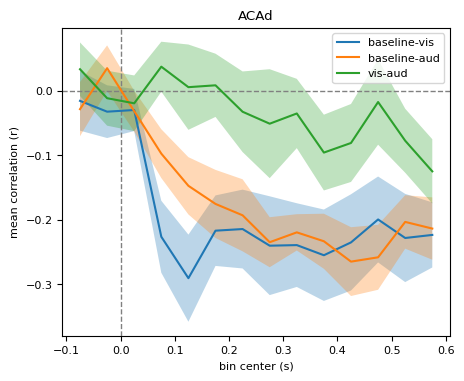

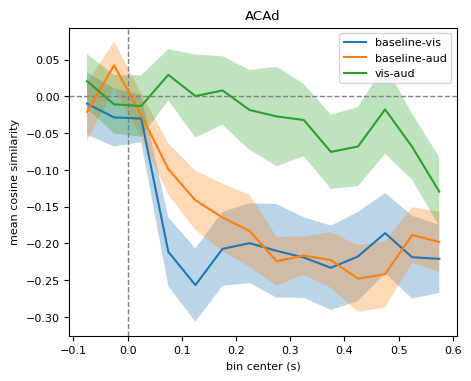

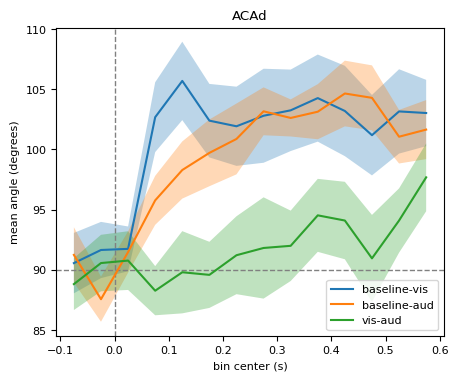

In [225]:
# arrange into session x bin_center matrix, with separate matrices for correlation r values, p values, and cosine similarity, and separate matrices for baseline-vis, baseline-aud, and vis-aud comparisons

sel_structure='ACAd'

z_transform=True

plot_data=context_dimension_comparison_df.query('structure==@sel_structure and session_id in @dr_good_behavior_list')

xbins=plot_data.query('structure==@sel_structure')['bin_center'].unique()

baseline_vis_corr_matrix = plot_data.query('structure==@sel_structure').pivot(index='session_id', columns='bin_center', values='baseline_vis_corr_r')
baseline_aud_corr_matrix = plot_data.query('structure==@sel_structure').pivot(index='session_id', columns='bin_center', values='baseline_aud_corr_r')
vis_aud_corr_matrix = plot_data.query('structure==@sel_structure').pivot(index='session_id', columns='bin_center', values='vis_aud_corr_r')

baseline_vis_cosine_matrix = plot_data.query('structure==@sel_structure').pivot(index='session_id', columns='bin_center', values='baseline_vis_cosine')
baseline_aud_cosine_matrix = plot_data.query('structure==@sel_structure').pivot(index='session_id', columns='bin_center', values='baseline_aud_cosine')
vis_aud_cosine_matrix = plot_data.query('structure==@sel_structure').pivot(index='session_id', columns='bin_center', values='vis_aud_cosine')

baseline_vis_angle_matrix = plot_data.query('structure==@sel_structure').pivot(index='session_id', columns='bin_center', values='baseline_vis_angle')
baseline_aud_angle_matrix = plot_data.query('structure==@sel_structure').pivot(index='session_id', columns='bin_center', values='baseline_aud_angle')
vis_aud_angle_matrix = plot_data.query('structure==@sel_structure').pivot(index='session_id', columns='bin_center', values='vis_aud_angle')

#should compute mean after fishers z transform, then inverse transform for plotting

if z_transform:
    baseline_vis_corr_mean=np.tanh(np.arctanh(baseline_vis_corr_matrix.values).mean(axis=0))
    baseline_vis_corr_sem=np.tanh(stats.sem(np.arctanh(baseline_vis_corr_matrix.values),axis=0,nan_policy='omit'))
    baseline_aud_corr_mean=np.tanh(np.arctanh(baseline_aud_corr_matrix.values).mean(axis=0))
    baseline_aud_corr_sem=np.tanh(stats.sem(np.arctanh(baseline_aud_corr_matrix.values),axis=0,nan_policy='omit'))
    vis_aud_corr_mean=np.tanh(np.arctanh(vis_aud_corr_matrix.values).mean(axis=0))
    vis_aud_corr_sem=np.tanh(stats.sem(np.arctanh(vis_aud_corr_matrix.values),axis=0,nan_policy='omit'))
else:
    baseline_vis_corr_mean=np.nanmean(baseline_vis_corr_matrix.values,axis=0)
    baseline_vis_corr_sem=stats.sem(baseline_vis_corr_matrix.values,axis=0,nan_policy='omit')
    baseline_aud_corr_mean=np.nanmean(baseline_aud_corr_matrix.values,axis=0)
    baseline_aud_corr_sem=stats.sem(baseline_aud_corr_matrix.values,axis=0,nan_policy='omit')
    vis_aud_corr_mean=np.nanmean(vis_aud_corr_matrix.values,axis=0)
    vis_aud_corr_sem=stats.sem(vis_aud_corr_matrix.values,axis=0,nan_policy='omit')

baseline_vis_cosine_mean=np.nanmean(baseline_vis_cosine_matrix.values,axis=0)
baseline_vis_cosine_sem=stats.sem(baseline_vis_cosine_matrix.values,axis=0,nan_policy='omit')
baseline_aud_cosine_mean=np.nanmean(baseline_aud_cosine_matrix.values,axis=0)
baseline_aud_cosine_sem=stats.sem(baseline_aud_cosine_matrix.values,axis=0,nan_policy='omit')
vis_aud_cosine_mean=np.nanmean(vis_aud_cosine_matrix.values,axis=0)
vis_aud_cosine_sem=stats.sem(vis_aud_cosine_matrix.values,axis=0,nan_policy='omit')

baseline_vis_angle_mean=np.nanmean(baseline_vis_angle_matrix.values,axis=0)
baseline_vis_angle_sem=stats.sem(baseline_vis_angle_matrix.values,axis=0,nan_policy='omit')
baseline_aud_angle_mean=np.nanmean(baseline_aud_angle_matrix.values,axis=0)
baseline_aud_angle_sem=stats.sem(baseline_aud_angle_matrix.values,axis=0,nan_policy='omit')
vis_aud_angle_mean=np.nanmean(vis_aud_angle_matrix.values,axis=0)
vis_aud_angle_sem=stats.sem(vis_aud_angle_matrix.values,axis=0,nan_policy='omit')


fig,ax=plt.subplots(figsize=(5,4))
ax.axhline(0, color='gray', linestyle='--', linewidth=1)
ax.axvline(0, color='gray', linestyle='--', linewidth=1)
ax.plot(xbins, baseline_vis_corr_mean, label='baseline-vis')
ax.fill_between(xbins, baseline_vis_corr_mean-baseline_vis_corr_sem, baseline_vis_corr_mean+baseline_vis_corr_sem, alpha=0.3)
ax.plot(xbins, baseline_aud_corr_mean, label='baseline-aud')
ax.fill_between(xbins, baseline_aud_corr_mean-baseline_aud_corr_sem, baseline_aud_corr_mean+baseline_aud_corr_sem, alpha=0.3)
ax.plot(xbins, vis_aud_corr_mean, label='vis-aud')
ax.fill_between(xbins, vis_aud_corr_mean-vis_aud_corr_sem, vis_aud_corr_mean+vis_aud_corr_sem, alpha=0.3)
ax.legend()
ax.set_xlabel('bin center (s)')
ax.set_ylabel('mean correlation (r)')
ax.set_title(sel_structure)


fig,ax=plt.subplots(figsize=(5,4))
ax.axhline(0, color='gray', linestyle='--', linewidth=1)
ax.axvline(0, color='gray', linestyle='--', linewidth=1)
ax.plot(xbins, baseline_vis_cosine_mean, label='baseline-vis')
ax.fill_between(xbins, baseline_vis_cosine_mean-baseline_vis_cosine_sem, baseline_vis_cosine_mean+baseline_vis_cosine_sem, alpha=0.3)
ax.plot(xbins, baseline_aud_cosine_mean, label='baseline-aud')
ax.fill_between(xbins, baseline_aud_cosine_mean-baseline_aud_cosine_sem, baseline_aud_cosine_mean+baseline_aud_cosine_sem, alpha=0.3)
ax.plot(xbins, vis_aud_cosine_mean, label='vis-aud')
ax.fill_between(xbins, vis_aud_cosine_mean-vis_aud_cosine_sem, vis_aud_cosine_mean+vis_aud_cosine_sem, alpha=0.3)
ax.legend()
ax.set_xlabel('bin center (s)')
ax.set_ylabel('mean cosine similarity')
ax.set_title(sel_structure)

fig,ax=plt.subplots(figsize=(5,4))
ax.axhline(90, color='gray', linestyle='--', linewidth=1)
ax.axvline(0, color='gray', linestyle='--', linewidth=1)
ax.plot(xbins, baseline_vis_angle_mean, label='baseline-vis')
ax.fill_between(xbins, baseline_vis_angle_mean-baseline_vis_angle_sem, baseline_vis_angle_mean+baseline_vis_angle_sem, alpha=0.3)
ax.plot(xbins, baseline_aud_angle_mean, label='baseline-aud')
ax.fill_between(xbins, baseline_aud_angle_mean-baseline_aud_angle_sem, baseline_aud_angle_mean+baseline_aud_angle_sem, alpha=0.3)
ax.plot(xbins, vis_aud_angle_mean, label='vis-aud')
ax.fill_between(xbins, vis_aud_angle_mean-vis_aud_angle_sem, vis_aud_angle_mean+vis_aud_angle_sem, alpha=0.3)
ax.legend()
ax.set_xlabel('bin center (s)')
ax.set_ylabel('mean angle (degrees)')
ax.set_title(sel_structure)

In [151]:
np.arctanh(baseline_vis_corr_matrix.values).mean(axis=0)

array([-0.0283236 , -0.05355588, -0.05117609, -0.08470405, -0.16437551,
       -0.1838818 , -0.20121175, -0.2059416 , -0.20492966, -0.2016523 ,
       -0.19831383, -0.2003883 , -0.19471627, -0.21474334])

In [205]:
#limit to structures with higher decoding accuracy

loadpath=r"D:\decoding_results_from_CO\baseline_loose_drift_2026-05-14\structure_wise_decoding_accuracy_10_units.parquet"
# loadpath=r"D:\decoding_results_from_CO\baseline_loose_drift_2026-05-14\structure_wise_decoding_accuracy_20_units.parquet"
structure_wise_decoding_accuracy=pd.read_parquet(loadpath)

context_decoding_structures=structure_wise_decoding_accuracy.query('(mean_diff>=0.04 or mean_true>=0.65)')['structure'].values
context_decoding_structures

array(['CUN', 'PPN', 'NPC', 'OT', 'PP', 'SCm', 'FF', 'MRN', 'RR', 'PAR',
       'PH', 'AMv', 'GPe', 'AMd', 'RN', 'SAG', 'CP', 'FRP', 'OP', 'ICe',
       'BST', 'ACAd', 'SNr', 'AId', 'PL', 'MH', 'ZI', 'PIL', 'MOs', 'AIp',
       'VISa', 'PAG', 'LT', 'VM', 'MPO', 'SMT', 'MOp', 'AV', 'SSs',
       'CEAm', 'ORBl', 'MPT', 'POL', 'VPLpc', 'PF', 'RT', 'VPL', 'LHA',
       'SSp', 'LH', 'CL', 'DP', 'Eth', 'TEa', 'VISC', 'SCs', 'PoT',
       'AUDv', 'VTA', 'GU', 'GPi', 'ORBvl', 'HPF', 'PCN', 'ECT', 'VAL',
       'VISal', 'MD', 'SH', 'ILA', 'AD', 'OLF', 'ProS', 'APN', 'VPM',
       'SGN', 'SF', 'VISpm', 'LP', 'SUM'], dtype=object)

In [220]:
# also filter by stimulus responsiveness??
#>5% of units respond to at least one stimulus??

stim_resp_path=r"\\allen\programs\mindscope\workgroups\dynamicrouting\Ethan\CO single unit metrics\v272_2025-08-15\data\area_fraction_responsive_to_stim.csv"
stim_resp_table=pd.read_csv(stim_resp_path)

# stim_resp_table.columns

stim_resp_table['any_stim_responsive']=stim_resp_table[['vis1', 'vis2', 'sound1', 'sound2', 'both_vis', 'both_sound', 'mixed',]].sum(axis=1)

stim_resp_table.query('n_sessions_w_10_units >= 3').sort_values(by='any_stim_responsive', ascending=False).head(20)

stim_resp_table.query('n_sessions_w_10_units >= 3 and any_stim_responsive>=0.10').sort_values(by='any_stim_responsive', ascending=False)

,Unnamed: 0,area,vis1,vis2,sound1,sound2,both_vis,both_sound,mixed,none,...,sound2_neg,both_vis_neg,both_sound_neg,mixed_neg,total_n,n_sessions,n_sessions_w_20_units,n_sessions_w_15_units,n_sessions_w_10_units,any_stim_responsive
86,86,MRN,0.047847,0.009569,0.040072,0.049641,0.032895,0.208732,0.267943,0.270933,...,0.013158,0.005383,0.036483,0.042464,1672,62,37,41,47,0.656699
192,192,FF,0.054348,0.000000,0.000000,0.141304,0.043478,0.217391,0.184783,0.326087,...,0.021739,0.000000,0.021739,0.032609,92,10,1,3,3,0.641304
120,120,ZI,0.054974,0.013089,0.057592,0.078534,0.062827,0.185864,0.175393,0.308901,...,0.013089,0.005236,0.015707,0.010471,382,30,8,13,17,0.628272
89,89,SCdg,0.067460,0.015873,0.063492,0.043651,0.051587,0.170635,0.214286,0.281746,...,0.007937,0.000000,0.035714,0.027778,252,33,1,2,7,0.626984
98,98,SCiw,0.048611,0.004630,0.028935,0.040509,0.067130,0.199074,0.229167,0.285880,...,0.011574,0.011574,0.026620,0.030093,864,53,15,24,35,0.618056
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
50,50,TTd,0.000000,0.001692,0.010152,0.032149,0.001692,0.065990,0.010152,0.876481,...,0.006768,0.000000,0.008460,0.000000,591,21,10,15,18,0.121827
7,7,CA1,0.015997,0.002232,0.014137,0.037946,0.008557,0.034598,0.004836,0.874628,...,0.014881,0.000744,0.002232,0.000000,2688,99,50,64,80,0.118304
73,73,ACB,0.013468,0.000000,0.023569,0.043771,0.000000,0.030303,0.006734,0.875421,...,0.006734,0.000000,0.000000,0.000000,297,21,4,6,12,0.117845
175,175,CLA,0.000000,0.000000,0.031250,0.046875,0.000000,0.031250,0.000000,0.875000,...,0.015625,0.000000,0.000000,0.000000,64,6,1,1,3,0.109375


In [206]:
#compare across areas

sel_bin_center=0.125

#create area-average table with mean and sem correlation and cosine similarity and angles plus number of sessions

area_average_df = {
    'structure':[],
    'n_sessions':[],
    'baseline_vis_corr_mean':[],
    'baseline_vis_corr_sem':[],
    'baseline_aud_corr_mean':[],
    'baseline_aud_corr_sem':[],
    'vis_aud_corr_mean':[],
    'vis_aud_corr_sem':[],
    'baseline_vis_cosine_mean':[],
    'baseline_vis_cosine_sem':[],
    'baseline_aud_cosine_mean':[],
    'baseline_aud_cosine_sem':[],
    'vis_aud_cosine_mean':[],
    'vis_aud_cosine_sem':[],
    'baseline_vis_angle_mean':[],
    'baseline_vis_angle_sem':[],
    'baseline_aud_angle_mean':[],
    'baseline_aud_angle_sem':[],
    'vis_aud_angle_mean':[],
    'vis_aud_angle_sem':[],
}

for sel_structure in context_dimension_comparison_df['structure'].unique():

    temp_df=context_dimension_comparison_df.query('structure==@sel_structure and bin_center==@sel_bin_center and session_id in @dr_good_behavior_list')
    n_sessions=temp_df['session_id'].nunique()
    
    area_average_df['structure'].append(sel_structure)
    area_average_df['n_sessions'].append(n_sessions)
    area_average_df['baseline_vis_corr_mean'].append(np.tanh(np.arctanh(temp_df['baseline_vis_corr_r']).mean()))
    area_average_df['baseline_vis_corr_sem'].append(np.tanh(stats.sem(np.arctanh(temp_df['baseline_vis_corr_r']),nan_policy='omit')))
    area_average_df['baseline_aud_corr_mean'].append(np.tanh(np.arctanh(temp_df['baseline_aud_corr_r']).mean()))
    area_average_df['baseline_aud_corr_sem'].append(np.tanh(stats.sem(np.arctanh(temp_df['baseline_aud_corr_r']),nan_policy='omit')))
    area_average_df['vis_aud_corr_mean'].append(np.tanh(np.arctanh(temp_df['vis_aud_corr_r']).mean()))
    area_average_df['vis_aud_corr_sem'].append(np.tanh(stats.sem(np.arctanh(temp_df['vis_aud_corr_r']),nan_policy='omit')))
    area_average_df['baseline_vis_cosine_mean'].append(temp_df['baseline_vis_cosine'].mean())
    area_average_df['baseline_vis_cosine_sem'].append(stats.sem(temp_df['baseline_vis_cosine'],nan_policy='omit'))
    area_average_df['baseline_aud_cosine_mean'].append(temp_df['baseline_aud_cosine'].mean())
    area_average_df['baseline_aud_cosine_sem'].append(stats.sem(temp_df['baseline_aud_cosine'],nan_policy='omit'))
    area_average_df['vis_aud_cosine_mean'].append(temp_df['vis_aud_cosine'].mean())
    area_average_df['vis_aud_cosine_sem'].append(stats.sem(temp_df['vis_aud_cosine'],nan_policy='omit'))
    area_average_df['baseline_vis_angle_mean'].append(temp_df['baseline_vis_angle'].mean())
    area_average_df['baseline_vis_angle_sem'].append(stats.sem(temp_df['baseline_vis_angle'],nan_policy='omit'))
    area_average_df['baseline_aud_angle_mean'].append(temp_df['baseline_aud_angle'].mean())
    area_average_df['baseline_aud_angle_sem'].append(stats.sem(temp_df['baseline_aud_angle'],nan_policy='omit'))
    area_average_df['vis_aud_angle_mean'].append(temp_df['vis_aud_angle'].mean())
    area_average_df['vis_aud_angle_sem'].append(stats.sem(temp_df['vis_aud_angle'],nan_policy='omit'))

area_average_df = pd.DataFrame(area_average_df)
area_average_df

C:\Users\ethan.mcbride\AppData\Local\Temp\ipykernel_38256\3989092717.py:38: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  area_average_df['baseline_vis_corr_sem'].append(np.tanh(stats.sem(np.arctanh(temp_df['baseline_vis_corr_r']),nan_policy='omit')))
C:\Users\ethan.mcbride\AppData\Local\Temp\ipykernel_38256\3989092717.py:40: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  area_average_df['baseline_aud_corr_sem'].append(np.tanh(stats.sem(np.arctanh(temp_df['baseline_aud_corr_r']),nan_policy='omit')))
C:\Users\ethan.mcbride\AppData\Local\Temp\ipykernel_38256\3989092717.py:42: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  area_average_df['vis_aud_corr_sem'].append(np.tanh(stats.sem(np.arctanh(te

,structure,n_sessions,baseline_vis_corr_mean,baseline_vis_corr_sem,baseline_aud_corr_mean,baseline_aud_corr_sem,vis_aud_corr_mean,vis_aud_corr_sem,baseline_vis_cosine_mean,baseline_vis_cosine_sem,baseline_aud_cosine_mean,baseline_aud_cosine_sem,vis_aud_cosine_mean,vis_aud_cosine_sem,baseline_vis_angle_mean,baseline_vis_angle_sem,baseline_aud_angle_mean,baseline_aud_angle_sem,vis_aud_angle_mean,vis_aud_angle_sem
0,AUDp,5,-0.100741,0.045033,-0.316095,0.117025,0.094198,0.034679,-0.104992,0.040987,-0.288502,0.101036,0.083932,0.030917,96.042579,2.359269,107.327445,6.439636,85.175989,1.779352
1,AUDpo,6,-0.148806,0.095882,-0.182035,0.088812,0.078952,0.081018,-0.156482,0.084327,-0.175590,0.081353,0.061087,0.071499,99.175453,4.930305,100.317229,4.820304,86.405145,4.186949
2,CA1,51,-0.198697,0.027859,-0.136486,0.034825,0.042357,0.030212,-0.186697,0.025403,-0.131858,0.030253,0.038273,0.027519,100.957252,1.511639,97.711488,1.807464,87.691300,1.640224
3,CP,65,-0.170750,0.025587,-0.169285,0.026115,0.005575,0.026159,-0.176411,0.024134,-0.167269,0.022981,0.006626,0.023939,100.308869,1.425320,99.838423,1.382331,89.639094,1.404278
4,DG,38,-0.167954,0.052667,-0.110257,0.042621,-0.024985,0.043160,-0.151637,0.033594,-0.096999,0.035597,-0.031083,0.038328,99.029124,2.076324,95.568407,2.115517,91.855312,2.264897
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
127,FF,1,-0.221560,NaN,0.011297,NaN,-0.330666,NaN,-0.240120,NaN,0.030825,NaN,-0.345975,NaN,103.893604,NaN,88.233566,NaN,110.241301,NaN
128,SPFp,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
129,VPMpc,2,-0.324377,0.124120,-0.122567,0.033407,-0.365755,0.103143,-0.377951,0.069522,-0.079539,0.010158,-0.393726,0.051594,112.273125,4.308541,94.562285,0.583852,113.225317,3.218496
130,LA,1,-0.515659,NaN,-0.105481,NaN,0.222289,NaN,-0.524256,NaN,-0.131232,NaN,0.231652,NaN,121.618203,NaN,97.540790,NaN,76.605646,NaN


Text(0.5, 1.0, 'context dimension correlation, n_sessions>=4')

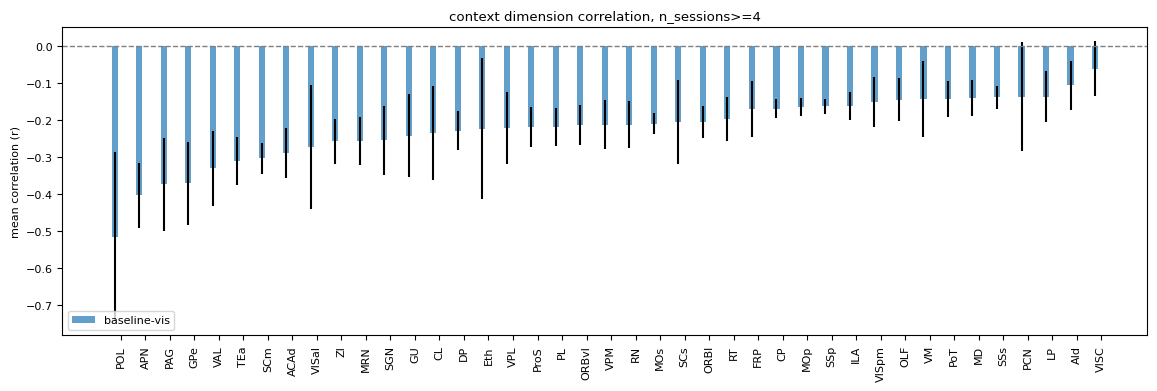

In [229]:
# plot, sort by baseline-vis correlation
min_n_sessions=4
plot_df = area_average_df.query('n_sessions >= @min_n_sessions and structure in @context_decoding_structures').sort_values('baseline_vis_corr_mean', ascending=True)
xvect=np.arange(plot_df.shape[0])

fig,ax=plt.subplots(figsize=(14,4))
# ax.bar(x='structure', y='baseline_vis_corr_mean', yerr='baseline_vis_corr_sem', label='baseline-vis')
# ax.bar(x='structure', y='baseline_aud_corr_mean', yerr='baseline_aud_corr_sem', label='baseline-aud')
# ax.bar(x='structure', y='vis_aud_corr_mean', yerr='vis_aud_corr_sem', label='vis-aud')
ax.bar(xvect-0.25, plot_df['baseline_vis_corr_mean'], yerr=plot_df['baseline_vis_corr_sem'], label='baseline-vis',width=0.25, align='center', alpha=0.7)
# ax.bar(xvect, plot_df['baseline_aud_corr_mean'], yerr=plot_df['baseline_aud_corr_sem'], label='baseline-aud', width=0.25, align='center', alpha=0.7)
# ax.bar(xvect+0.25, plot_df['vis_aud_corr_mean'], yerr=plot_df['vis_aud_corr_sem'], label='vis-aud', width=0.25, align='center', alpha=0.7)
ax.axhline(0, color='gray', linestyle='--', linewidth=1)
ax.set_xticks(xvect)
ax.set_xticklabels(plot_df['structure'], rotation=90, ha='center')
ax.legend()
ax.set_ylabel('mean correlation (r)')
ax.set_title(f'context dimension correlation, n_sessions>={min_n_sessions}')